# 🧠 LSTM 原理交互式演示
## —— 从数学直觉到荧光图像视频处理

**LSTM (Long Short-Term Memory)** 是一种特殊的循环神经网络(RNN)，专为解决长序列中的信息记忆问题而设计。本 Notebook 将通过交互式可视化，帮助你直观理解 LSTM 的工作原理，并展示其在 **荧光图像/视频处理** 中的实际应用。

---

### 📋 目录
1. [引言与背景](#Section-1) — 为什么需要 LSTM？
2. [LSTM 单元结构可视化](#Section-2) — 拆解三个门
3. [门控机制交互实验](#Section-3) — 动手调节参数
4. [LSTM vs RNN 对比实验](#Section-4) — 用数据说话
5. [荧光信号模拟与时序建模](#Section-5) — 预测荧光强度
6. [荧光视频逐帧预测](#Section-6) — ConvLSTM 应用
7. [荧光事件检测](#Section-7) — LSTM 分类器
8. [总结与延伸](#Section-8)

In [9]:
# 📦 导入所需库
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox

import torch
import torch.nn as nn
import torch.optim as optim

# 设置随机种子保证可重复性
np.random.seed(42)
torch.manual_seed(42)

# ===== Matplotlib 中文字体设置 =====
# macOS 使用系统自带的苹方字体; Linux/Windows 可改为 'SimHei' 或 'WenQuanYi Micro Hei'
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'SimHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['figure.dpi'] = 100

print("✅ 所有库导入成功！")
print(f"   PyTorch 版本: {torch.__version__}")
print(f"   NumPy 版本: {np.__version__}")
print(f"   字体设置: {matplotlib.rcParams['font.sans-serif']}")

✅ 所有库导入成功！
   PyTorch 版本: 1.12.0
   NumPy 版本: 1.24.3
   字体设置: ['PingFang SC', 'Heiti SC', 'SimHei', 'Arial Unicode MS']


---
## Section 1: 引言与背景 — 为什么需要 LSTM？

### 时序数据中的"记忆"问题

在处理时序数据时（如荧光视频的逐帧信号），模型需要**记住**之前的信息来理解当前状态。传统 RNN 通过隐藏状态 $h_t$ 传递信息：

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b)$$

**问题：** 当序列变长时，RNN 会遭遇 **梯度消失/爆炸** 问题 — 早期信息在多层传递中被指数级衰减或放大，导致网络"遗忘"远期信息。

**LSTM 的解决方案：** 引入 **细胞状态 $C_t$** — 一条贯穿时间步的"信息高速公路"，通过三个门控机制精确控制信息的读取、写入和遗忘。

👇 运行下面的代码，直观感受 RNN vs LSTM 在长程记忆上的差异。

/var/folders/0r/w4xk_f1s0yjbn38ffy83cvj00000gn/T/ipykernel_70177/1138143495.py:47: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/var/folders/0r/w4xk_f1s0yjbn38ffy83cvj00000gn/T/ipykernel_70177/1138143495.py:47: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()


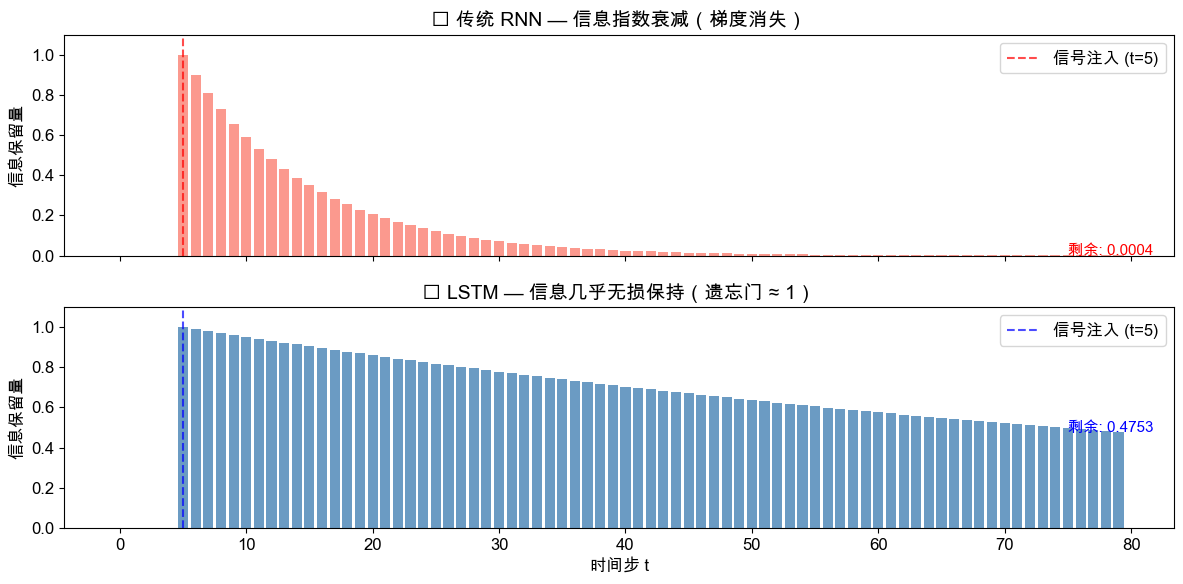


📊 对比：经过 75 步传递后：
   RNN  信息保留: 0.000411  (几乎全部丢失！)
   LSTM 信息保留: 0.475340  (依然清晰！)

💡 这就是 LSTM 在处理长时序荧光视频时的核心优势：
   例如第1帧中粒子出现的信息，可以保持到第80帧仍在影响预测。


In [10]:
# 🎬 Section 1: RNN 梯度消失 vs LSTM 长程记忆 — 动画演示
# 模拟简单 RNN 和 LSTM 在传递信息时的衰减/保持行为

T = 80  # 时间步总数
signal_start = 5  # 信号出现的时间步

# --- RNN 的信息衰减模拟 ---
# RNN 中信息按 (W_hh)^t 衰减，假设 |W_hh| = 0.9
W_hh_rnn = 0.9
rnn_memory = np.zeros(T)
rnn_memory[signal_start] = 1.0  # 在第5步注入信号
for t in range(signal_start + 1, T):
    rnn_memory[t] = W_hh_rnn * rnn_memory[t-1]  # 每步衰减

# --- LSTM 的信息保持模拟 ---
# LSTM 中遗忘门接近1时，信息几乎无损传递
f_gate = 0.99  # 遗忘门输出
lstm_memory = np.zeros(T)
lstm_memory[signal_start] = 1.0
for t in range(signal_start + 1, T):
    lstm_memory[t] = f_gate * lstm_memory[t-1]  # 几乎不衰减

# --- 可视化 ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# RNN
axes[0].bar(range(T), rnn_memory, color='salmon', alpha=0.8, width=0.8)
axes[0].axvline(x=signal_start, color='red', linestyle='--', alpha=0.7, label=f'信号注入 (t={signal_start})')
axes[0].set_ylabel('信息保留量', fontsize=12)
axes[0].set_title('🔴 传统 RNN — 信息指数衰减（梯度消失）', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].set_ylim(0, 1.1)
axes[0].annotate(f'剩余: {rnn_memory[-1]:.4f}', xy=(T-5, rnn_memory[-1]),
                fontsize=11, color='red', fontweight='bold')

# LSTM
axes[1].bar(range(T), lstm_memory, color='steelblue', alpha=0.8, width=0.8)
axes[1].axvline(x=signal_start, color='blue', linestyle='--', alpha=0.7, label=f'信号注入 (t={signal_start})')
axes[1].set_xlabel('时间步 t', fontsize=12)
axes[1].set_ylabel('信息保留量', fontsize=12)
axes[1].set_title('🔵 LSTM — 信息几乎无损保持（遗忘门 ≈ 1）', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].set_ylim(0, 1.1)
axes[1].annotate(f'剩余: {lstm_memory[-1]:.4f}', xy=(T-5, lstm_memory[-1]),
                fontsize=11, color='blue', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 对比：经过 {T - signal_start} 步传递后：")
print(f"   RNN  信息保留: {rnn_memory[-1]:.6f}  (几乎全部丢失！)")
print(f"   LSTM 信息保留: {lstm_memory[-1]:.6f}  (依然清晰！)")
print(f"\n💡 这就是 LSTM 在处理长时序荧光视频时的核心优势：")
print(f"   例如第1帧中粒子出现的信息，可以保持到第80帧仍在影响预测。")

---
## Section 2: LSTM 单元结构可视化

LSTM 的核心是 **细胞状态 $C_t$** 和三个 **门控机制**：

### 🚪 三个门

| 门 | 公式 | 作用 |
|---|---|---|
| **遗忘门** | $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$ | 决定从细胞状态中**丢弃**什么 |
| **输入门** | $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$ | 决定**写入**什么新信息 |
| **输出门** | $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$ | 决定**输出**什么信息 |

### 🔄 状态更新

$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C) \quad \text{(候选细胞状态)}$$

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \quad \text{(更新细胞状态)}$$

$$h_t = o_t \odot \tanh(C_t) \quad \text{(输出隐藏状态)}$$

其中 $\sigma$ 是 sigmoid 函数（输出 0~1，作为"开关"），$\odot$ 是逐元素乘法。

👇 运行下方代码查看 LSTM 单元的完整结构图。

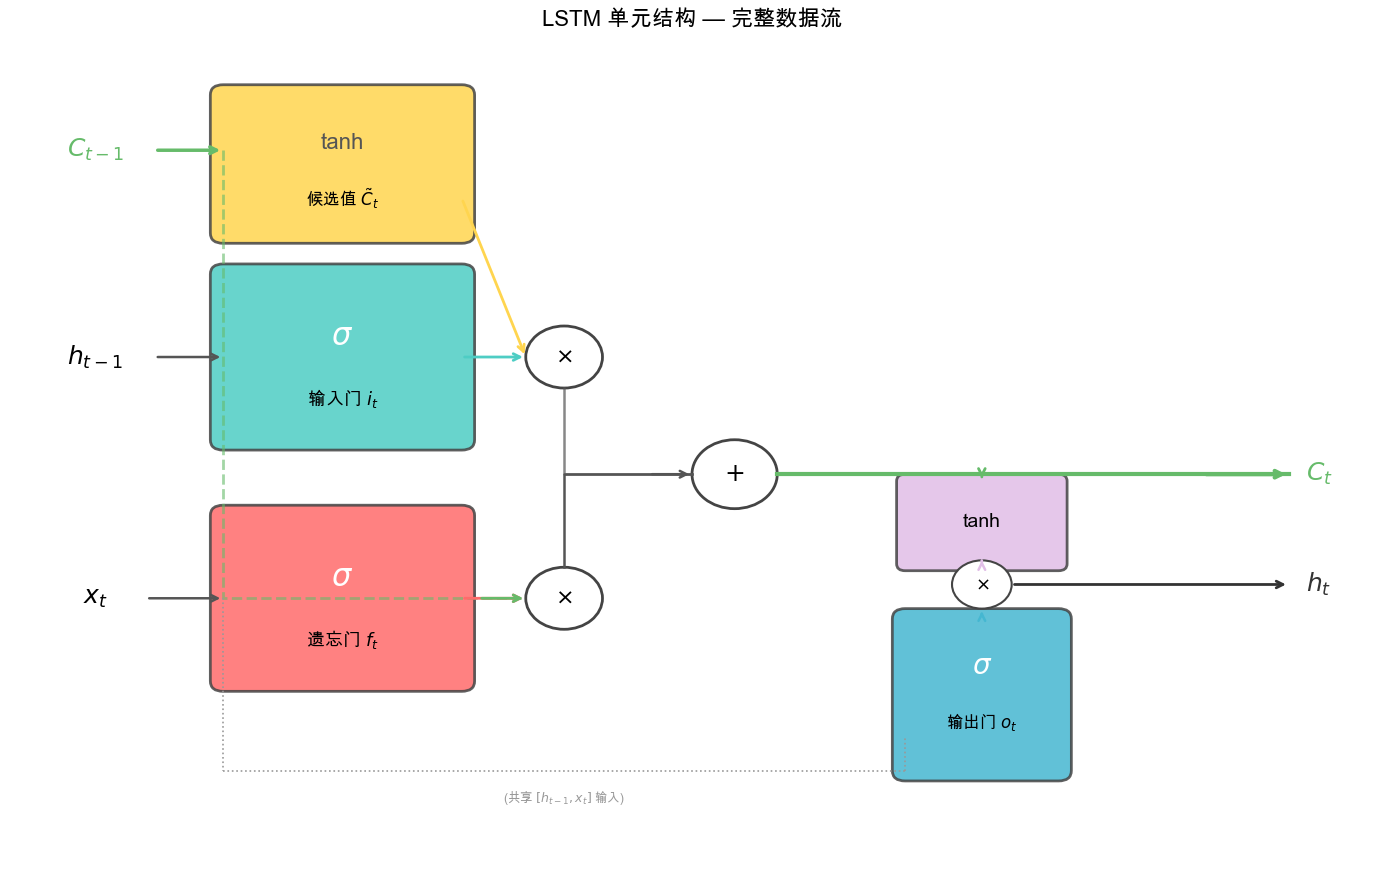

👆 LSTM 单元完整数据流
💡 使用下方控件，逐个高亮每个门查看其数据流：


In [11]:
# 🎨 Section 2: LSTM 单元结构图 — 交互式可视化
# 使用 matplotlib 绘制 LSTM 单元的数据流图，可逐步高亮每个门

def draw_lstm_cell(highlight_gate=None):
    """绘制 LSTM 单元结构图 — 清晰版"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 9))
    ax.set_xlim(-1, 15)
    ax.set_ylim(-1, 11)
    ax.axis('off')

    # 颜色
    C = {
        'forget': '#FF6B6B', 'input': '#4ECDC4', 'output': '#45B7D1',
        'cell': '#66BB6A', 'candidate': '#FFD54F', 'dim': '#E0E0E0',
        'op': '#78909C',  # 运算节点
    }

    def clr(name):
        if highlight_gate is None or highlight_gate == name:
            return C[name]
        return C['dim']

    fc, ic, oc, cc = clr('forget'), clr('input'), clr('output'), clr('candidate')

    # ========== 1. 输入标签 (左侧) ==========
    ax.text(0, 3.0, r'$x_t$', fontsize=18, fontweight='bold', ha='center', va='center')
    ax.text(0, 6.5, r'$h_{t-1}$', fontsize=18, fontweight='bold', ha='center', va='center')
    ax.text(0, 9.5, r'$C_{t-1}$', fontsize=18, fontweight='bold', ha='center', va='center', color=C['cell'])

    # ========== 2. 输入连线 ==========
    ax.annotate('', xy=(1.5, 3.0), xytext=(0.6, 3.0),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.8))
    ax.annotate('', xy=(1.5, 6.5), xytext=(0.7, 6.5),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.8))
    ax.annotate('', xy=(1.5, 9.5), xytext=(0.7, 9.5),
                arrowprops=dict(arrowstyle='->', color=C['cell'], lw=2.5))

    # ========== 3. 遗忘门 (下方) ==========
    box_f = mpatches.FancyBboxPatch((1.5, 1.8), 2.8, 2.4,
        boxstyle="round,pad=0.15", facecolor=fc, edgecolor='#444', lw=2, alpha=0.85)
    ax.add_patch(box_f)
    ax.text(2.9, 3.3, r'$\sigma$', fontsize=22, ha='center', va='center', fontweight='bold', color='#fff')
    ax.text(2.9, 2.4, r'遗忘门 $f_t$', fontsize=13, ha='center', va='center', fontweight='bold')

    # ========== 4. 输入门 (中间) ==========
    box_i = mpatches.FancyBboxPatch((1.5, 5.3), 2.8, 2.4,
        boxstyle="round,pad=0.15", facecolor=ic, edgecolor='#444', lw=2, alpha=0.85)
    ax.add_patch(box_i)
    ax.text(2.9, 6.8, r'$\sigma$', fontsize=22, ha='center', va='center', fontweight='bold', color='#fff')
    ax.text(2.9, 5.9, r'输入门 $i_t$', fontsize=13, ha='center', va='center', fontweight='bold')

    # ========== 5. 候选值 (上方) ==========
    box_c = mpatches.FancyBboxPatch((1.5, 8.3), 2.8, 2.0,
        boxstyle="round,pad=0.15", facecolor=cc, edgecolor='#444', lw=2, alpha=0.85)
    ax.add_patch(box_c)
    ax.text(2.9, 9.6, r'tanh', fontsize=16, ha='center', va='center', fontweight='bold', color='#555')
    ax.text(2.9, 8.8, r'候选值 $\tilde{C}_t$', fontsize=12, ha='center', va='center', fontweight='bold')

    # ========== 6. 运算: × (遗忘) ==========
    circ1 = mpatches.Circle((5.5, 3.0), 0.45, facecolor='#fff', edgecolor='#444', lw=2)
    ax.add_patch(circ1)
    ax.text(5.5, 3.0, r'$\times$', fontsize=16, ha='center', va='center', fontweight='bold')

    # 连线: f_t → ×
    ax.annotate('', xy=(5.05, 3.0), xytext=(4.3, 3.0),
                arrowprops=dict(arrowstyle='->', color=fc, lw=2))
    # 连线: C_{t-1} ↓ to ×  (折线)
    ax.plot([1.5, 1.5, 5.0], [9.5, 3.0, 3.0], color=C['cell'], lw=2, ls='--', alpha=0.6)
    ax.annotate('', xy=(5.05, 3.0), xytext=(4.5, 3.0),
                arrowprops=dict(arrowstyle='->', color=C['cell'], lw=2))

    # ========== 7. 运算: × (输入) ==========
    circ2 = mpatches.Circle((5.5, 6.5), 0.45, facecolor='#fff', edgecolor='#444', lw=2)
    ax.add_patch(circ2)
    ax.text(5.5, 6.5, r'$\times$', fontsize=16, ha='center', va='center', fontweight='bold')

    # 连线: i_t → ×
    ax.annotate('', xy=(5.05, 6.5), xytext=(4.3, 6.5),
                arrowprops=dict(arrowstyle='->', color=ic, lw=2))
    # 连线: C̃_t → ×
    ax.annotate('', xy=(5.05, 6.5), xytext=(4.3, 8.8),
                arrowprops=dict(arrowstyle='->', color=cc, lw=2))

    # ========== 8. 运算: + (加法) ==========
    circ3 = mpatches.Circle((7.5, 4.8), 0.5, facecolor='#fff', edgecolor='#444', lw=2)
    ax.add_patch(circ3)
    ax.text(7.5, 4.8, r'$+$', fontsize=18, ha='center', va='center', fontweight='bold')

    # 连线: ×(遗忘) → +  (折线向下)
    ax.plot([5.5, 5.5, 7.0], [3.45, 4.8, 4.8], color='#555', lw=1.8)
    ax.annotate('', xy=(7.0, 4.8), xytext=(6.5, 4.8),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.8))

    # 连线: ×(输入) → +  (折线向下)
    ax.plot([5.5, 5.5, 7.0], [6.05, 4.8, 4.8], color='#555', lw=1.8, alpha=0.7)

    # ========== 9. C_t 输出 (右侧水平线) ==========
    ax.plot([8.0, 14.0], [4.8, 4.8], color=C['cell'], lw=3)
    ax.annotate('', xy=(14.0, 4.8), xytext=(13.0, 4.8),
                arrowprops=dict(arrowstyle='->', color=C['cell'], lw=3))
    ax.text(14.2, 4.8, r'$C_t$', fontsize=18, fontweight='bold', va='center', color=C['cell'])

    # ========== 10. tanh 节点 ==========
    box_tanh = mpatches.FancyBboxPatch((9.5, 3.5), 1.8, 1.2,
        boxstyle="round,pad=0.1", facecolor='#E1BEE7', edgecolor='#444', lw=2, alpha=0.85)
    ax.add_patch(box_tanh)
    ax.text(10.4, 4.1, r'tanh', fontsize=14, ha='center', va='center', fontweight='bold')

    # 连线: C_t → tanh  (竖线向下)
    ax.annotate('', xy=(10.4, 4.7), xytext=(10.4, 4.8),
                arrowprops=dict(arrowstyle='->', color=C['cell'], lw=2))

    # ========== 11. 输出门 ==========
    box_o = mpatches.FancyBboxPatch((9.5, 0.5), 1.8, 2.2,
        boxstyle="round,pad=0.15", facecolor=oc, edgecolor='#444', lw=2, alpha=0.85)
    ax.add_patch(box_o)
    ax.text(10.4, 2.0, r'$\sigma$', fontsize=20, ha='center', va='center', fontweight='bold', color='#fff')
    ax.text(10.4, 1.2, r'输出门 $o_t$', fontsize=12, ha='center', va='center', fontweight='bold')

    # 输入门/遗忘门/候选值 → 输出门 的隐式连接 (简化: 一条虚线)
    ax.plot([1.5, 1.5], [3.0, 0.5], color='#999', lw=1.2, ls=':')
    ax.plot([1.5, 9.5], [0.5, 0.5], color='#999', lw=1.2, ls=':')
    ax.plot([9.5, 9.5], [0.5, 1.0], color='#999', lw=1.2, ls=':')
    ax.text(5.5, 0.1, r'(共享 $[h_{t-1}, x_t]$ 输入)', fontsize=9, ha='center',
            va='center', color='#999', style='italic')

    # ========== 12. 运算: × (输出) ==========
    circ4 = mpatches.Circle((10.4, 3.2), 0.35, facecolor='#fff', edgecolor='#444', lw=1.5)
    ax.add_patch(circ4)
    ax.text(10.4, 3.2, r'$\times$', fontsize=13, ha='center', va='center', fontweight='bold')

    # 连线: o_t → ×
    ax.annotate('', xy=(10.4, 2.85), xytext=(10.4, 2.7),
                arrowprops=dict(arrowstyle='->', color=oc, lw=1.8))
    # 连线: tanh → ×
    ax.annotate('', xy=(10.4, 3.55), xytext=(10.4, 3.5),
                arrowprops=dict(arrowstyle='->', color='#E1BEE7', lw=1.8))

    # ========== 13. h_t 输出 ==========
    ax.annotate('', xy=(14.0, 3.2), xytext=(10.75, 3.2),
                arrowprops=dict(arrowstyle='->', color='#333', lw=2))
    ax.text(14.2, 3.2, r'$h_t$', fontsize=18, fontweight='bold', va='center', color='#333')

    # ========== 标题 ==========
    gate_names = {'forget': '遗忘门 (Forget)', 'input': '输入门 (Input)', 'output': '输出门 (Output)'}
    if highlight_gate:
        title = f'LSTM 单元结构 — 高亮: {gate_names[highlight_gate]}'
    else:
        title = 'LSTM 单元结构 — 完整数据流'
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)

    plt.tight_layout()
    plt.show()


# 先展示完整结构
draw_lstm_cell(highlight_gate=None)
print("👆 LSTM 单元完整数据流")
print("💡 使用下方控件，逐个高亮每个门查看其数据流：")

In [12]:
# 🎛️ 交互控件：选择高亮哪个门
@interact(highlight=widgets.Dropdown(
    options=[('全部显示', None), ('遗忘门 (Forget Gate)', 'forget'), 
             ('输入门 (Input Gate)', 'input'), ('输出门 (Output Gate)', 'output')],
    value=None,
    description='高亮门:',
    style={'description_width': 'initial'}
))
def interactive_lstm_cell(highlight):
    draw_lstm_cell(highlight_gate=highlight)

interactive(children=(Dropdown(description='高亮门:', options=(('全部显示', None), ('遗忘门 (Forget Gate)', 'forget'), (…

---
## Section 3: 门控机制交互实验

LSTM 的核心是三个 **sigmoid 门**（输出 0~1）和一个 **tanh 激活**（输出 -1~1）。通过交互式调节这些值，你可以直观感受每个门如何控制信息流动。

### 🧪 实验设计
- **左图**：sigmoid 和 tanh 函数曲线，当前参数值标注在曲线上
- **右图**：一个简化的 LSTM 时间步展开，显示 $C_{t-1} \rightarrow C_t$ 和 $h_t$ 的计算过程
- **滑块**：调节 $f_t$, $i_t$, $\tilde{C}_t$, $o_t$ 的值

> 💡 **关键直觉**：
> - $f_t \approx 0$ → 遗忘一切旧信息；$f_t \approx 1$ → 完全保留
> - $i_t \approx 0$ → 不写入新信息；$i_t \approx 1$ → 完全写入
> - $o_t \approx 0$ → 不输出；$o_t \approx 1$ → 完全输出

In [13]:
# 🎛️ Section 3: 门控机制交互实验

@interact(
    f_t=FloatSlider(min=0, max=1, step=0.01, value=0.8, description='遗忘门 f_t'),
    i_t=FloatSlider(min=0, max=1, step=0.01, value=0.5, description='输入门 i_t'),
    C_tilde=FloatSlider(min=-1, max=1, step=0.01, value=0.6, description='候选值 C̃_t'),
    o_t=FloatSlider(min=0, max=1, step=0.01, value=0.7, description='输出门 o_t'),
    C_prev=FloatSlider(min=-2, max=2, step=0.01, value=1.0, description='上一步 C_{t-1}'),
)
def gate_experiment(f_t, i_t, C_tilde, o_t, C_prev):
    # LSTM 计算
    C_t = f_t * C_prev + i_t * C_tilde
    h_t = o_t * np.tanh(C_t)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # --- 左图：激活函数 ---
    x = np.linspace(-4, 4, 200)
    axes[0].plot(x, 1 / (1 + np.exp(-x)), 'b-', lw=2, label='σ(x) sigmoid')
    axes[0].plot(x, np.tanh(x), 'r-', lw=2, label='tanh(x)')
    axes[0].axhline(y=f_t, color='blue', linestyle=':', alpha=0.5)
    axes[0].axhline(y=C_tilde, color='red', linestyle=':', alpha=0.5)
    axes[0].set_title('激活函数', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].set_ylim(-1.3, 1.3)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlabel('输入 x')

    # --- 中图：门控计算过程（柱状图） ---
    labels = ['f_t×C_{t-1}', 'i_t×C̃_t', 'C_t', 'tanh(C_t)', 'o_t×tanh(C_t)', 'h_t']
    values = [f_t * C_prev, i_t * C_tilde, C_t, np.tanh(C_t), o_t * np.tanh(C_t), h_t]
    bar_colors = ['#FF6B6B', '#4ECDC4', '#96CEB4', '#DDA0DD', '#45B7D1', '#333333']

    bars = axes[1].bar(range(len(labels)), values, color=bar_colors, alpha=0.8, edgecolor='#333')
    axes[1].set_xticks(range(len(labels)))
    axes[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    axes[1].set_title('计算分解', fontsize=13, fontweight='bold')
    axes[1].axhline(y=0, color='black', lw=0.5)
    axes[1].grid(True, axis='y', alpha=0.3)

    # 标注数值
    for bar, val in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # --- 右图：多步模拟 ---
    T_sim = 20
    C_history = [C_prev]
    h_history = [0]
    c = C_prev
    for t in range(1, T_sim):
        c_new = f_t * c + i_t * C_tilde
        h_new = o_t * np.tanh(c_new)
        C_history.append(c_new)
        h_history.append(h_new)
        c = c_new

    axes[2].plot(range(T_sim), C_history, 'g-o', ms=4, lw=2, label='C_t (细胞状态)')
    axes[2].plot(range(T_sim), h_history, 'b-s', ms=4, lw=2, label='h_t (隐藏状态)')
    axes[2].set_title('多步传递模拟', fontsize=13, fontweight='bold')
    axes[2].legend(fontsize=9)
    axes[2].set_xlabel('时间步')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"📊 单步计算结果：")
    print(f"   遗忘: f_t × C_{{t-1}} = {f_t:.2f} × {C_prev:.2f} = {f_t*C_prev:.3f}")
    print(f"   写入: i_t × C̃_t  = {i_t:.2f} × {C_tilde:.2f} = {i_t*C_tilde:.3f}")
    print(f"   细胞: C_t         = {C_t:.3f}")
    print(f"   输出: h_t         = {o_t:.2f} × tanh({C_t:.2f}) = {h_t:.3f}")

interactive(children=(FloatSlider(value=0.8, description='遗忘门 f_t', max=1.0, step=0.01), FloatSlider(value=0.5…

---
## Section 4: LSTM vs RNN 对比实验

现在用真实的 PyTorch 模型来对比！我们构造一个 **长程依赖任务**：

> 🎯 **任务**：序列的第1个值决定了整个序列的类别 — 模型需要"记住"开头的信息，直到最后才能做出预测。

这是 RNN 最容易失败的场景，也是 LSTM 大放异彩的地方。

📊 数据形状: X=torch.Size([800, 50, 1]), y=torch.Size([800])
   类别分布: 0→372, 1→428
   序列长度: 50 步 (信息在第1步，预测在第50步)


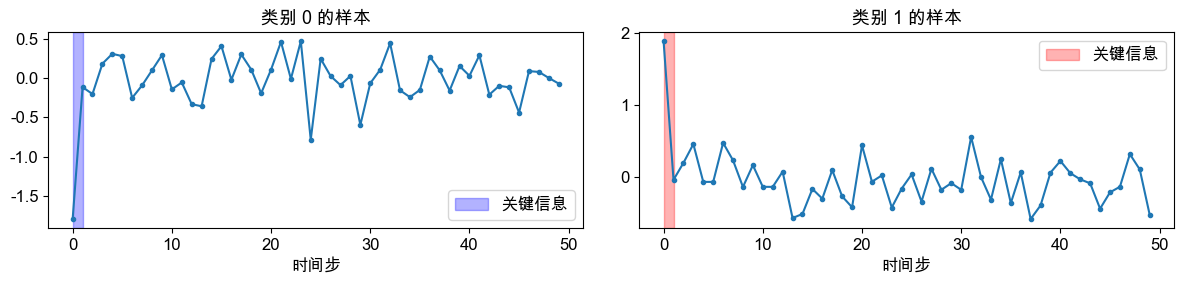

In [14]:
# 🧪 Section 4: LSTM vs RNN 对比实验
# 长程依赖任务：序列第1个值 → 二分类

# ===== 1. 生成合成数据 =====
def generate_long_dep_data(n_samples=500, seq_len=50, noise_std=0.3):
    """生成需要长程记忆的二分类数据
    类别由序列第1个值决定，中间全是噪声"""
    X = np.random.randn(n_samples, seq_len) * noise_std
    y = np.zeros(n_samples)
    
    for i in range(n_samples):
        # 第一个值决定类别
        if np.random.rand() > 0.5:
            X[i, 0] = 1.5 + np.random.randn() * 0.3  # 类别1
            y[i] = 1
        else:
            X[i, 0] = -1.5 + np.random.randn() * 0.3  # 类别0
            y[i] = 0
        # 中间步骤全是噪声（没有类别信息）
    
    return torch.FloatTensor(X).unsqueeze(-1), torch.LongTensor(y)

X_data, y_data = generate_long_dep_data(n_samples=800, seq_len=50)
X_train, y_train = X_data[:600], y_data[:600]
X_test, y_test = X_data[600:], y_data[600:]

print(f"📊 数据形状: X={X_data.shape}, y={y_data.shape}")
print(f"   类别分布: 0→{(y_data==0).sum()}, 1→{(y_data==1).sum()}")
print(f"   序列长度: {X_data.shape[1]} 步 (信息在第1步，预测在第50步)")

# 可视化两条样本
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for cls in [0, 1]:
    idx = (y_data == cls).nonzero()[0][0].item()
    axes[cls].plot(X_data[idx].numpy(), 'o-', ms=3)
    axes[cls].set_title(f'类别 {cls} 的样本', fontsize=13, fontweight='bold')
    axes[cls].set_xlabel('时间步')
    axes[cls].axvspan(0, 1, alpha=0.3, color='red' if cls==1 else 'blue', label='关键信息')
    axes[cls].legend()
plt.tight_layout()
plt.show()

In [ ]:
# ===== 2. 定义 RNN 和 LSTM 模型 =====

class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_classes=2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])  # 取最后时间步

class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# ===== 3. 训练函数 =====
def train_model(model, X_train, y_train, X_test, y_test, epochs=80, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses, test_accs = [], []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        model.eval()
        with torch.no_grad():
            test_out = model(X_test)
            pred = test_out.argmax(dim=1)
            acc = (pred == y_test).float().mean().item()
            test_accs.append(acc)
    
    return train_losses, test_accs

# ===== 4. 训练两个模型 =====
print("🏋️ 训练 RNN...")
rnn_model = SimpleRNN()
rnn_losses, rnn_accs = train_model(rnn_model, X_train, y_train, X_test, y_test, epochs=80)

print("🏋️ 训练 LSTM...")
lstm_model = SimpleLSTM()
lstm_losses, lstm_accs = train_model(lstm_model, X_train, y_train, X_test, y_test, epochs=80)

print("✅ 训练完成！")

🏋️ 训练 RNN...
🏋️ 训练 LSTM...
✅ 训练完成！


/var/folders/0r/w4xk_f1s0yjbn38ffy83cvj00000gn/T/ipykernel_70177/1408217160.py:69: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/var/folders/0r/w4xk_f1s0yjbn38ffy83cvj00000gn/T/ipykernel_70177/1408217160.py:69: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/var/folders/0r/w4xk_f1s0yjbn38ffy83cvj00000gn/T/ipykernel_70177/1408217160.py:69: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/opt/anaconda3/envs/d2l/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/d2l/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial Unicode MS.
  fig.ca

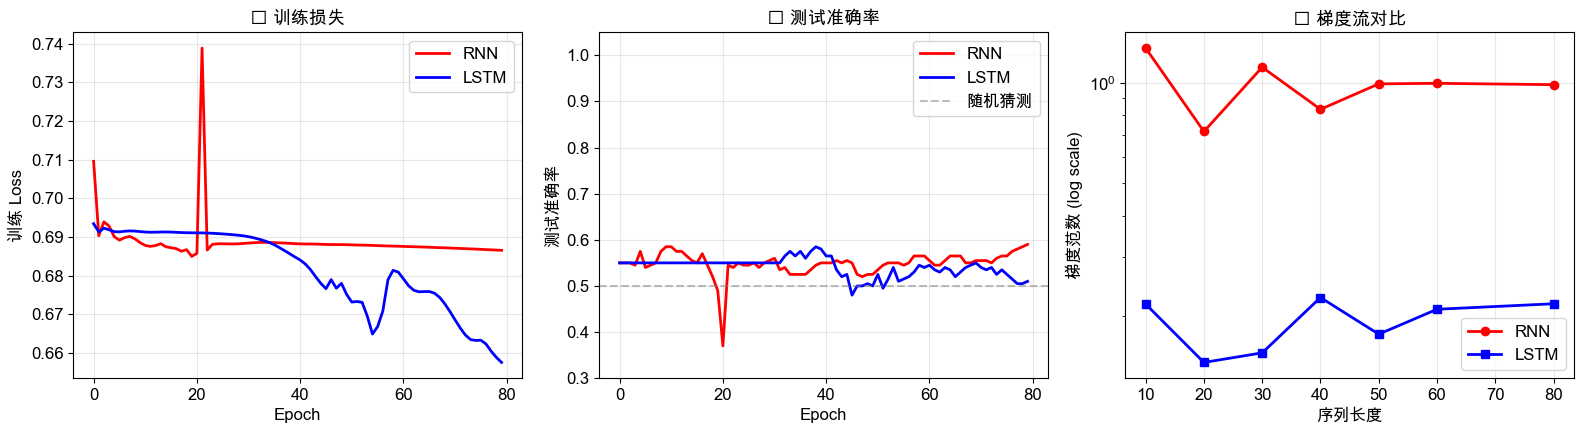


📊 最终测试准确率：
   RNN:  59.0%
   LSTM: 51.0%

💡 结论：在长程依赖任务中，LSTM 显著优于 RNN，因为：
   - RNN 的梯度随序列长度指数衰减 → 无法记住开头信息
   - LSTM 的门控机制让梯度可以直接流过细胞状态 → 长程记忆得以保持


In [17]:
# ===== 5. 可视化对比结果 =====

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 训练 Loss
axes[0].plot(rnn_losses, 'r-', lw=2, label='RNN')
axes[0].plot(lstm_losses, 'b-', lw=2, label='LSTM')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('训练 Loss')
axes[0].set_title('📉 训练损失', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 测试准确率
axes[1].plot(rnn_accs, 'r-', lw=2, label='RNN')
axes[1].plot(lstm_accs, 'b-', lw=2, label='LSTM')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='随机猜测')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('测试准确率')
axes[1].set_title('📈 测试准确率', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.3, 1.05)

# 梯度流对比
def get_gradient_norms(model, X_sample, model_type='rnn'):
    """获取各时间步的梯度范数"""
    model.train()
    out = model(X_sample)
    loss = out.sum()
    loss.backward()
    
    if model_type == 'rnn':
        weights = model.rnn.weight_hh_l0
    else:
        weights = model.lstm.weight_hh_l0
    
    grad_norm = weights.grad.norm().item()
    model.zero_grad()
    return grad_norm

# 计算不同序列长度下的梯度
seq_lengths = [10, 20, 30, 40, 50, 60, 80]
rnn_grads, lstm_grads = [], []

for sl in seq_lengths:
    X_sl = torch.randn(1, sl, 1)
    rnn_g = SimpleRNN()
    lstm_g = SimpleLSTM()
    
    rnn_out = rnn_g(X_sl)
    rnn_out.sum().backward()
    rnn_grads.append(rnn_g.rnn.weight_hh_l0.grad.norm().item())
    rnn_g.zero_grad()
    
    lstm_out = lstm_g(X_sl)
    lstm_out.sum().backward()
    lstm_grads.append(lstm_g.lstm.weight_hh_l0.grad.norm().item())
    lstm_g.zero_grad()

axes[2].semilogy(seq_lengths, rnn_grads, 'r-o', lw=2, ms=6, label='RNN')
axes[2].semilogy(seq_lengths, lstm_grads, 'b-s', lw=2, ms=6, label='LSTM')
axes[2].set_xlabel('序列长度')
axes[2].set_ylabel('梯度范数 (log scale)')
axes[2].set_title('🌊 梯度流对比', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 总结
rnn_final = rnn_accs[-1]
lstm_final = lstm_accs[-1]
print(f"\n{'='*50}")
print(f"📊 最终测试准确率：")
print(f"   RNN:  {rnn_final:.1%}")
print(f"   LSTM: {lstm_final:.1%}")
print(f"{'='*50}")
print(f"\n💡 结论：在长程依赖任务中，LSTM 显著优于 RNN，因为：")
print(f"   - RNN 的梯度随序列长度指数衰减 → 无法记住开头信息")
print(f"   - LSTM 的门控机制让梯度可以直接流过细胞状态 → 长程记忆得以保持")

---
## Section 5: 荧光信号模拟与时序建模

现在进入与 **Lab-on-Chip 荧光成像** 相关的应用！

### 🔬 荧光信号特征
在微流控芯片荧光成像中，典型信号包含：
1. **基线荧光**：背景荧光水平
2. **荧光事件**：粒子/细胞经过检测区域时的脉冲信号（快速上升 + 指数衰减）
3. **光漂白**：随时间缓慢衰减的趋势（荧光染料逐渐失活）
4. **噪声**：探测器噪声（高斯分布）

### 🎯 任务
用 LSTM 学习荧光时间序列的模式，**预测下一帧的荧光强度** — 这对实时荧光成像中的噪声抑制、异常检测非常有用。

In [ ]:
# 🔬 Section 5: 荧光信号模拟与时序建模

def generate_fluorescence_signal(T=500, baseline=5.0, noise_std=0.3,
                                  n_events=8, event_decay=0.05,
                                  bleach_rate=0.002, event_amplitude=3.0):
    """生成模拟荧光时间序列
    
    参数:
        T: 时间步数
        baseline: 基线荧光强度
        noise_std: 噪声标准差
        n_events: 荧光事件数量
        event_decay: 事件衰减速率（越大衰减越快）
        bleach_rate: 光漂白速率
        event_amplitude: 事件幅度
    """
    t = np.arange(T)
    
    # 1. 基线 + 光漂白
    signal = baseline * np.exp(-bleach_rate * t)
    
    # 2. 荧光事件（随机时刻出现的指数衰减脉冲）
    event_times = np.sort(np.random.randint(10, T - 50, size=n_events))
    event_mask = np.zeros(T)  # 用于标注事件位置
    
    for evt_t in event_times:
        # 快速上升 + 指数衰减
        duration = min(40, T - evt_t)
        pulse = event_amplitude * np.exp(-event_decay * np.arange(duration))
        signal[evt_t:evt_t + duration] += pulse
        event_mask[evt_t:evt_t + min(10, duration)] = 1  # 标注上升沿
    
    # 3. 噪声
    signal += np.random.randn(T) * noise_std
    
    return signal, event_times, event_mask

# 生成默认信号
signal, event_times, event_mask = generate_fluorescence_signal()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# 信号 + 事件标注
axes[0].plot(signal, 'g-', lw=1, alpha=0.8, label='荧光信号')
for et in event_times:
    axes[0].axvline(x=et, color='red', linestyle='--', alpha=0.4)
axes[0].set_ylabel('荧光强度 (a.u.)', fontsize=12)
axes[0].set_title('🔬 模拟荧光时间序列 — Lab-on-Chip 成像场景', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 分解：各组成部分
T = len(signal)
t = np.arange(T)
baseline_component = 5.0 * np.exp(-0.002 * t)
axes[1].plot(baseline_component, 'b--', lw=1.5, alpha=0.7, label='基线+光漂白')
axes[1].plot(signal - baseline_component, 'g-', lw=1, alpha=0.6, label='信号-基线 (事件+噪声)')
axes[1].axhline(y=0, color='black', lw=0.5)
axes[1].set_xlabel('时间步 (帧)', fontsize=12)
axes[1].set_ylabel('强度 (a.u.)', fontsize=12)
axes[1].set_title('信号分解', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"📊 信号统计: 均值={signal.mean():.2f}, 标准差={signal.std():.2f}, 事件数={len(event_times)}")

In [ ]:
# ===== LSTM 荧光信号预测 =====

class FluorescencePredictor(nn.Module):
    """LSTM 荧光强度预测器"""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def prepare_sequences(signal, window_size=20):
    """将信号切割为滑动窗口序列"""
    X, y = [], []
    for i in range(len(signal) - window_size):
        X.append(signal[i:i + window_size])
        y.append(signal[i + window_size])
    X = torch.FloatTensor(np.array(X)).unsqueeze(-1)  # (N, window, 1)
    y = torch.FloatTensor(np.array(y)).unsqueeze(-1)   # (N, 1)
    return X, y

# 生成训练和测试数据
np.random.seed(42)
torch.manual_seed(42)

train_signal, _, _ = generate_fluorescence_signal(T=800)
test_signal, test_events, _ = generate_fluorescence_signal(T=400)

WINDOW = 20
X_train_fl, y_train_fl = prepare_sequences(train_signal, WINDOW)
X_test_fl, y_test_fl = prepare_sequences(test_signal, WINDOW)

# 训练
fl_model = FluorescencePredictor()
optimizer = optim.Adam(fl_model.parameters(), lr=0.005)
criterion = nn.MSELoss()

print("🏋️ 训练荧光预测 LSTM...")
for epoch in range(60):
    fl_model.train()
    optimizer.zero_grad()
    pred = fl_model(X_train_fl)
    loss = criterion(pred, y_train_fl)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        fl_model.eval()
        with torch.no_grad():
            test_pred = fl_model(X_test_fl)
            test_loss = criterion(test_pred, y_test_fl)
        print(f"   Epoch {epoch+1}: Train Loss={loss.item():.4f}, Test Loss={test_loss.item():.4f}")

print("✅ 训练完成！")

In [ ]:
# ===== 可视化预测结果 + 交互式参数调节 =====

fl_model.eval()
with torch.no_grad():
    predictions = fl_model(X_test_fl).numpy().flatten()

actual = y_test_fl.numpy().flatten()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# 预测 vs 真实
axes[0].plot(actual, 'g-', lw=1.2, alpha=0.7, label='真实荧光信号')
axes[0].plot(predictions, 'b-', lw=1.5, alpha=0.9, label='LSTM 预测')
for et in test_events:
    if et - WINDOW >= 0:
        axes[0].axvline(x=et - WINDOW, color='red', linestyle='--', alpha=0.3)
axes[0].set_ylabel('荧光强度 (a.u.)')
axes[0].set_title('🔬 LSTM 荧光信号预测 — 下一帧预测', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 预测误差
error = predictions - actual
axes[1].plot(error, 'r-', lw=1, alpha=0.8)
axes[1].axhline(y=0, color='black', lw=0.5)
axes[1].fill_between(range(len(error)), error, 0, alpha=0.2, color='red')
axes[1].set_xlabel('时间步')
axes[1].set_ylabel('预测误差')
axes[1].set_title(f'预测误差 (MSE={np.mean(error**2):.4f})', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 LSTM 能学到荧光信号的基线趋势和事件衰减模式，对漂白和脉冲都有较好的预测能力。")

In [ ]:
# 🎛️ 交互：调节荧光信号参数，观察 LSTM 预测表现

@interact(
    noise_level=FloatSlider(min=0.05, max=1.5, step=0.05, value=0.3, description='噪声水平'),
    n_events=IntSlider(min=1, max=20, step=1, value=8, description='事件数量'),
    bleach_rate=FloatSlider(min=0.0, max=0.01, step=0.0005, value=0.002, description='漂白速率'),
    event_amp=FloatSlider(min=0.5, max=8.0, step=0.5, value=3.0, description='事件幅度'),
)
def interactive_fluorescence(noise_level, n_events, bleach_rate, event_amp):
    # 生成新信号
    sig, evts, _ = generate_fluorescence_signal(
        T=400, noise_std=noise_level, n_events=n_events,
        bleach_rate=bleach_rate, event_amplitude=event_amp
    )
    
    # 准备数据
    X_int, y_int = prepare_sequences(sig, WINDOW)
    
    # 预测
    fl_model.eval()
    with torch.no_grad():
        preds = fl_model(X_int).numpy().flatten()
    
    actual = y_int.numpy().flatten()
    mse = np.mean((preds - actual) ** 2)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    
    axes[0].plot(actual, 'g-', lw=1, alpha=0.7, label='真实信号')
    axes[0].plot(preds, 'b-', lw=1.5, alpha=0.9, label='LSTM 预测')
    axes[0].set_title(f'荧光预测 — 噪声={noise_level:.2f}, 事件={n_events}, '
                      f'漂白={bleach_rate:.4f}, 幅度={event_amp:.1f}',
                      fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylabel('荧光强度')
    
    err = preds - actual
    axes[1].plot(err, 'r-', lw=1, alpha=0.8)
    axes[1].fill_between(range(len(err)), err, 0, alpha=0.2, color='red')
    axes[1].axhline(y=0, color='black', lw=0.5)
    axes[1].set_xlabel('时间步')
    axes[1].set_ylabel('预测误差')
    axes[1].set_title(f'MSE = {mse:.4f}', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 MSE={mse:.4f} | 信号SNR≈{(event_amp/noise_level):.1f}")
    print(f"   噪声越高、事件越弱 → 预测越困难")

---
## Section 6: LSTM 在荧光视频中的应用 — 逐帧预测

从1D信号升级到 **2D 荧光视频**！这里模拟微流控芯片上的荧光显微图像序列：
- 几个高斯发光点代表荧光标记的细胞/粒子
- 发光强度随时间波动（闪烁 + 光漂白 + 噪声）
- 粒子可能缓慢移动

我们使用 **Flatten → LSTM → Reshape** 的方式预测下一帧，直观展示 LSTM 如何学习时空模式。

In [ ]:
# 🎬 Section 6: 荧光视频模拟与逐帧预测

def generate_fluorescence_video(n_frames=60, height=32, width=32, n_particles=4,
                                 noise_std=0.05, bleach_rate=0.003):
    """生成模拟荧光视频（2D高斯粒子 + 漂白 + 噪声）
    
    返回: video (n_frames, H, W) 数组
    """
    np.random.seed(42)
    video = np.zeros((n_frames, height, width))
    y_grid, x_grid = np.mgrid[0:height, 0:width]
    
    # 每个粒子的参数
    particles = []
    for _ in range(n_particles):
        p = {
            'y': np.random.uniform(5, height - 5),
            'x': np.random.uniform(5, width - 5),
            'sigma': np.random.uniform(1.5, 3.0),
            'amplitude': np.random.uniform(0.5, 1.5),
            'vy': np.random.uniform(-0.05, 0.05),  # 缓慢移动
            'vx': np.random.uniform(-0.05, 0.05),
        }
        particles.append(p)
    
    for t in range(n_frames):
        frame = np.zeros((height, width))
        bleach_factor = np.exp(-bleach_rate * t)
        
        for p in particles:
            # 更新位置
            cy = p['y'] + p['vy'] * t
            cx = p['x'] + p['vx'] * t
            
            # 2D高斯
            gauss = p['amplitude'] * bleach_factor * np.exp(
                -((y_grid - cy)**2 + (x_grid - cx)**2) / (2 * p['sigma']**2)
            )
            # 添加闪烁（小幅随机波动）
            flicker = 1.0 + 0.1 * np.sin(0.3 * t + hash(str(p['x'])) % 10)
            frame += gauss * flicker
        
        # 添加噪声
        frame += np.random.randn(height, width) * noise_std
        video[t] = frame
    
    # 归一化到 [0, 1]
    video = np.clip(video, 0, None)
    if video.max() > 0:
        video = video / video.max()
    
    return video

# 生成视频
video = generate_fluorescence_video(n_frames=60, height=32, width=32, n_particles=4)

# 展示几帧
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
frame_indices = [0, 15, 30, 45, 59]
for ax, fi in zip(axes, frame_indices):
    im = ax.imshow(video[fi], cmap='hot', vmin=0, vmax=1)
    ax.set_title(f'帧 {fi}', fontsize=12, fontweight='bold')
    ax.axis('off')
fig.colorbar(im, ax=axes, shrink=0.6, label='荧光强度')
plt.suptitle('🔬 模拟荧光视频 — 微流控芯片粒子', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
print(f"📊 视频形状: {video.shape} (帧×高×宽)")

In [ ]:
# ===== LSTM 逐帧预测 =====

class VideoPredictor(nn.Module):
    """Flatten → LSTM → Reshape 视频预测器"""
    def __init__(self, input_dim=1024, hidden_size=256, num_layers=2):
        super().__init__()
        self.input_dim = input_dim
        self.lstm = nn.LSTM(input_dim, hidden_size, num_layers,
                           batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_size, input_dim)
    
    def forward(self, x):
        # x: (batch, seq_len, input_dim) — 已 flatten
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# 准备视频数据
H, W = 32, 32
flat_dim = H * W  # 1024

def prepare_video_data(video, window=5):
    """将视频切割为滑动窗口序列（flatten后）"""
    n_frames = video.shape[0]
    X, y = [], []
    for i in range(n_frames - window):
        # window帧作为输入，预测下一帧
        seq = video[i:i+window].reshape(window, -1)  # (window, 1024)
        target = video[i+window].reshape(-1)           # (1024,)
        X.append(seq)
        y.append(target)
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y))

# 生成更多训练视频
torch.manual_seed(42)
print("📹 生成训练视频...")
train_videos = [generate_fluorescence_video(n_frames=60, height=H, width=W) 
                for _ in range(5)]
X_train_vid, y_train_vid = [], []
for v in train_videos:
    Xv, yv = prepare_video_data(v, window=5)
    X_train_vid.append(Xv)
    y_train_vid.append(yv)
X_train_vid = torch.cat(X_train_vid)
y_train_vid = torch.cat(y_train_vid)

# 测试视频
test_video = generate_fluorescence_video(n_frames=60, height=H, width=W)
X_test_vid, y_test_vid = prepare_video_data(test_video, window=5)

# 训练
vid_model = VideoPredictor(input_dim=flat_dim, hidden_size=256)
vid_optimizer = optim.Adam(vid_model.parameters(), lr=0.001)
vid_criterion = nn.MSELoss()

print("🏋️ 训练视频预测 LSTM...")
for epoch in range(50):
    vid_model.train()
    vid_optimizer.zero_grad()
    pred = vid_model(X_train_vid)
    loss = vid_criterion(pred, y_train_vid)
    loss.backward()
    vid_optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"   Epoch {epoch+1}: Loss={loss.item():.6f}")

print("✅ 训练完成！")

In [ ]:
# ===== 可视化：原始帧 vs 预测帧 vs 误差热图 =====

vid_model.eval()
with torch.no_grad():
    pred_frames = vid_model(X_test_vid).numpy()

actual_frames = y_test_vid.numpy()

# 选择几个时间点展示
show_frames = [5, 15, 25, 35, 45]
fig, axes = plt.subplots(3, len(show_frames), figsize=(15, 9))

for col, fi in enumerate(show_frames):
    # 原始帧
    axes[0, col].imshow(actual_frames[fi].reshape(H, W), cmap='hot', vmin=0, vmax=1)
    axes[0, col].set_title(f't={fi+5}', fontsize=11, fontweight='bold')
    axes[0, col].axis('off')
    
    # 预测帧
    pred_img = np.clip(pred_frames[fi].reshape(H, W), 0, 1)
    axes[1, col].imshow(pred_img, cmap='hot', vmin=0, vmax=1)
    axes[1, col].axis('off')
    
    # 误差热图
    error = np.abs(pred_img - actual_frames[fi].reshape(H, W))
    axes[2, col].imshow(error, cmap='Reds', vmin=0, vmax=0.3)
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('原始帧', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('LSTM预测', fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel('|误差|', fontsize=12, fontweight='bold')

plt.suptitle('🎬 LSTM 荧光视频逐帧预测', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 计算整体指标
mse_per_frame = np.mean((pred_frames - actual_frames)**2, axis=1)
print(f"📊 逐帧MSE: 均值={mse_per_frame.mean():.5f}, 最大={mse_per_frame.max():.5f}")

In [ ]:
# ===== 动画：荧光视频预测过程 =====

vid_model.eval()
with torch.no_grad():
    all_preds = vid_model(X_test_vid).numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

def update(frame_idx):
    for ax in axes:
        ax.clear()
    
    # 原始帧
    axes[0].imshow(actual_frames[frame_idx].reshape(H, W), cmap='hot', vmin=0, vmax=1)
    axes[0].set_title(f'原始帧 t={frame_idx+5}', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # 预测帧
    pred_img = np.clip(all_preds[frame_idx].reshape(H, W), 0, 1)
    axes[1].imshow(pred_img, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title('LSTM 预测', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # 误差
    error = np.abs(pred_img - actual_frames[frame_idx].reshape(H, W))
    axes[2].imshow(error, cmap='Reds', vmin=0, vmax=0.3)
    axes[2].set_title('|预测误差|', fontsize=12, fontweight='bold')
    axes[2].axis('off')

anim = FuncAnimation(fig, update, frames=len(actual_frames), interval=150, blit=False)
plt.tight_layout()
plt.close()  # 防止显示静态图

HTML(anim.to_jshtml())

---
## Section 7: 荧光事件检测 — LSTM 分类器

在荧光成像实验中，一个常见任务是 **自动检测"事件"** — 如粒子经过检测区域产生的荧光脉冲。这正是 LSTM 擅长的时序模式识别任务。

### 🎯 任务
在荧光时间序列中，实时检测每个时间步是否发生了"事件"（二分类）。

> 这对应实际场景：微流控芯片中荧光标记细胞/粒子经过焦点时产生脉冲信号，需要自动标注。

In [ ]:
# 🎯 Section 7: 荧光事件检测分类器

def generate_event_detection_data(n_sequences=100, seq_len=200, 
                                   noise_std=0.5, n_events_range=(2, 6)):
    """生成带事件标签的荧光序列，用于二分类"""
    X_all, y_all = [], []
    
    for _ in range(n_sequences):
        # 基线 + 噪声
        sig = np.random.randn(seq_len) * noise_std + 3.0
        
        # 添加光漂白
        sig *= np.exp(-0.002 * np.arange(seq_len))
        
        # 事件标签
        labels = np.zeros(seq_len)
        n_events = np.random.randint(*n_events_range)
        
        for _ in range(n_events):
            evt_start = np.random.randint(10, seq_len - 30)
            evt_duration = np.random.randint(8, 25)
            amplitude = np.random.uniform(2.0, 5.0)
            
            # 快速上升 + 指数衰减
            for j in range(evt_duration):
                t = evt_start + j
                if t < seq_len:
                    if j < 3:
                        sig[t] += amplitude * (j + 1) / 3  # 上升
                    else:
                        sig[t] += amplitude * np.exp(-0.15 * (j - 2))  # 衰减
                    labels[t] = 1
        
        X_all.append(sig)
        y_all.append(labels)
    
    return np.array(X_all), np.array(y_all)

# 生成数据
X_evt, y_evt = generate_event_detection_data(n_sequences=200, seq_len=200)

# 划分训练/测试
split = 150
X_evt_train = torch.FloatTensor(X_evt[:split]).unsqueeze(-1)  # (N, T, 1)
y_evt_train = torch.FloatTensor(y_evt[:split])
X_evt_test = torch.FloatTensor(X_evt[split:]).unsqueeze(-1)
y_evt_test = torch.FloatTensor(y_evt[split:])

print(f"📊 训练数据: {X_evt_train.shape}, 正样本比例: {y_evt_train.mean():.2%}")
print(f"📊 测试数据: {X_evt_test.shape}, 正样本比例: {y_evt_test.mean():.2%}")

# 可视化一条样本
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
sample_idx = 0
axes[0].plot(X_evt[sample_idx], 'g-', lw=1.2)
axes[0].set_title('🔬 荧光信号 + 事件标注', fontsize=13, fontweight='bold')
axes[0].set_ylabel('荧光强度')

# 高亮事件区域
for t in range(len(y_evt[sample_idx])):
    if y_evt[sample_idx, t] == 1:
        axes[0].axvspan(t - 0.5, t + 0.5, alpha=0.3, color='red')

axes[1].plot(y_evt[sample_idx], 'r-', lw=2)
axes[1].set_xlabel('时间步')
axes[1].set_ylabel('事件标签')
axes[1].set_title('事件标签 (0=无事件, 1=有事件)', fontsize=12)
axes[1].set_ylim(-0.1, 1.3)

plt.tight_layout()
plt.show()

In [ ]:
# ===== 训练 LSTM 事件检测器 =====

class EventDetector(nn.Module):
    """LSTM 事件检测器 — 逐帧二分类"""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        out, _ = self.lstm(x)         # (N, T, hidden)
        out = self.sigmoid(self.fc(out))  # (N, T, 1)
        return out.squeeze(-1)         # (N, T)

# 训练
evt_model = EventDetector()
evt_optimizer = optim.Adam(evt_model.parameters(), lr=0.003)

# 使用加权BCE loss（处理类别不平衡）
pos_weight = torch.tensor([(y_evt_train == 0).sum() / (y_evt_train == 1).sum()])
evt_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 重新定义带sigmoid的forward用于推理，训练时用BCEWithLogitsLoss
class EventDetectorTrain(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out).squeeze(-1)  # 返回 logits

evt_model = EventDetectorTrain()
evt_optimizer = optim.Adam(evt_model.parameters(), lr=0.003)

print("🏋️ 训练事件检测 LSTM...")
for epoch in range(40):
    evt_model.train()
    evt_optimizer.zero_grad()
    logits = evt_model(X_evt_train)
    loss = evt_criterion(logits, y_evt_train)
    loss.backward()
    evt_optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        evt_model.eval()
        with torch.no_grad():
            test_logits = evt_model(X_evt_test)
            test_loss = evt_criterion(test_logits, y_evt_test)
            probs = torch.sigmoid(test_logits)
            preds = (probs > 0.5).float()
            accuracy = (preds == y_evt_test).float().mean()
        print(f"   Epoch {epoch+1}: Loss={loss.item():.4f}, "
              f"Test Acc={accuracy:.2%}")

print("✅ 训练完成！")

In [ ]:
# ===== 可视化检测结果 + 交互式阈值调节 =====

evt_model.eval()
with torch.no_grad():
    test_probs = torch.sigmoid(evt_model(X_evt_test)).numpy()

# 默认阈值可视化
sample_idx = 2
threshold = 0.5
pred_labels = (test_probs[sample_idx] > threshold).astype(float)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# 信号 + 真实标注
axes[0].plot(X_evt_test[sample_idx].numpy(), 'g-', lw=1.2)
for t in range(len(y_evt_test[sample_idx])):
    if y_evt_test[sample_idx, t] == 1:
        axes[0].axvspan(t - 0.5, t + 0.5, alpha=0.3, color='green')
axes[0].set_ylabel('荧光强度')
axes[0].set_title('🔬 荧光信号 + 真实事件标注（绿色区域）', fontsize=13, fontweight='bold')

# LSTM 概率输出
axes[1].plot(test_probs[sample_idx], 'b-', lw=1.5, label='LSTM 事件概率')
axes[1].axhline(y=threshold, color='red', linestyle='--', lw=1.5, label=f'阈值={threshold}')
axes[1].set_ylabel('概率')
axes[1].set_title('LSTM 输出的事件概率', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim(-0.05, 1.05)

# 检测结果
axes[2].plot(pred_labels, 'r-', lw=2, label='LSTM 检测')
axes[2].plot(y_evt_test[sample_idx].numpy(), 'g--', lw=1.5, alpha=0.7, label='真实标签')
axes[2].set_xlabel('时间步')
axes[2].set_ylabel('事件标签')
axes[2].set_title('检测结果 vs 真实', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# 🎛️ 交互式阈值调节 — 观察 Precision/Recall 变化

@interact(
    threshold=FloatSlider(min=0.1, max=0.95, step=0.05, value=0.5, 
                          description='检测阈值'),
    sample_idx=IntSlider(min=0, max=len(X_evt_test)-1, step=1, value=2,
                         description='样本编号'),
)
def interactive_detection(threshold, sample_idx):
    pred_labels = (test_probs[sample_idx] > threshold).astype(float)
    true_labels = y_evt_test[sample_idx].numpy()
    
    # 计算 Precision / Recall
    TP = np.sum((pred_labels == 1) & (true_labels == 1))
    FP = np.sum((pred_labels == 1) & (true_labels == 0))
    FN = np.sum((pred_labels == 0) & (true_labels == 1))
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    
    # 信号
    axes[0].plot(X_evt_test[sample_idx].numpy(), 'g-', lw=1.2)
    for t in range(len(true_labels)):
        if true_labels[t] == 1:
            axes[0].axvspan(t - 0.5, t + 0.5, alpha=0.3, color='green')
    axes[0].set_ylabel('荧光强度')
    axes[0].set_title('🔬 荧光信号 + 真实事件', fontsize=13, fontweight='bold')
    
    # 概率 + 阈值
    axes[1].plot(test_probs[sample_idx], 'b-', lw=1.5)
    axes[1].axhline(y=threshold, color='red', linestyle='--', lw=2, 
                    label=f'阈值={threshold:.2f}')
    axes[1].set_ylabel('事件概率')
    axes[1].set_title('LSTM 事件概率', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].set_ylim(-0.05, 1.05)
    
    # 检测结果
    axes[2].plot(pred_labels, 'r-', lw=2, label='检测', alpha=0.8)
    axes[2].plot(true_labels, 'g--', lw=1.5, alpha=0.7, label='真实')
    axes[2].set_xlabel('时间步')
    axes[2].set_ylabel('标签')
    axes[2].set_title(f'检测结果 — P={precision:.1%}, R={recall:.1%}, F1={f1:.1%}',
                     fontsize=13, fontweight='bold')
    axes[2].legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 阈值={threshold:.2f}: Precision={precision:.1%}, Recall={recall:.1%}, F1={f1:.1%}")
    print(f"   TP={TP:.0f}, FP={FP:.0f}, FN={FN:.0f}")
    print(f"   💡 阈值↑ → Precision↑ Recall↓（更保守，少误报但可能漏检）")
    print(f"   💡 阈值↓ → Precision↓ Recall↑（更敏感，少漏检但可能误报）")

---
## Section 8: 总结与延伸

### 📝 本 Notebook 要点回顾

| Section | 内容 | 核心收获 |
|---------|------|----------|
| 1 | 引言与背景 | RNN 梯度消失问题 → LSTM 通过门控机制解决 |
| 2 | 单元结构可视化 | 细胞状态 $C_t$ 是信息高速公路，三个门精确控制读写 |
| 3 | 门控交互实验 | $f_t$ 控制遗忘，$i_t$ 控制写入，$o_t$ 控制输出 |
| 4 | LSTM vs RNN | 长程依赖任务中 LSTM 远超 RNN |
| 5 | 荧光信号预测 | LSTM 能学到基线漂移 + 事件脉冲模式 |
| 6 | 荧光视频预测 | Flatten→LSTM 可以做2D逐帧预测 |
| 7 | 荧光事件检测 | LSTM 逐帧分类 + 阈值调节实现自动检测 |

### 🔮 LSTM 的延伸方向

1. **GRU (Gated Recurrent Unit)**
   - 简化版 LSTM：合并遗忘门和输入门为"更新门"
   - 参数更少，训练更快，性能通常接近

2. **Bidirectional LSTM**
   - 正向 + 反向两个 LSTM，同时利用过去和未来的信息
   - 适合离线分析（非实时场景）

3. **Attention 机制**
   - 让模型自动关注序列中最重要的时间步
   - Transformer 就是 Attention 的极致扩展，已在许多时序任务中超越 LSTM

4. **ConvLSTM**
   - 将 LSTM 内部的矩阵乘法替换为卷积操作
   - 天然处理2D时空数据，适合荧光视频

5. **序列到序列 (Seq2Seq)**
   - Encoder-Decoder 架构
   - 适合变长输入到变长输出的任务（如荧光信号去噪）

### 🔬 在荧光成像中的实际应用建议

- **信号去噪**：用 LSTM 学习噪声模式，预测"干净"信号
- **异常检测**：训练 LSTM 建模正常荧光模式，异常偏差即为事件
- **多通道融合**：将多个荧光通道作为多变量输入，LSTM 可捕获通道间关联
- **实时处理**：LSTM 的递归特性天然适合逐帧实时处理

### 📚 推荐阅读

- Hochreiter & Schmidhuber, "Long Short-Term Memory", Neural Computation, 1997 — LSTM 原始论文
- Shi et al., "Convolutional LSTM Network: A Machine Learning Approach for Precipitation Nowcasting", NeurIPS 2015 — ConvLSTM
- Vaswani et al., "Attention Is All You Need", NeurIPS 2017 — Transformer

---

**🎉 感谢阅读！希望这个交互式 Notebook 帮助你直观理解了 LSTM 的原理及其在荧光成像中的应用。**

# Rnn/LSTM

In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子以保证结果可复现
torch.manual_seed(42)

# 定义序列长度和网络维度
seq_len = 100      # 序列长度（时间步数），设置长一点更容易观察到梯度消失
input_size = 10    # 输入特征维度
hidden_size = 20   # 隐藏层维度
batch_size = 1     # 批次大小

In [7]:
# 初始化 RNN 和 LSTM 的核心单元 (Cell)
# 使用 Cell 而不是直接用 nn.RNN，是为了方便我们手动循环并提取每一步的梯度
rnn_cell = nn.RNNCell(input_size, hidden_size)
lstm_cell = nn.LSTMCell(input_size, hidden_size)

with torch.no_grad():
    # 将遗忘门的偏置初始化为 1.0，强制打开“高速公路”
    lstm_cell.bias_ih[hidden_size:2*hidden_size].fill_(1.0)
    lstm_cell.bias_hh[hidden_size:2*hidden_size].fill_(1.0)

# 随机生成一个输入序列
inputs = torch.randn(seq_len, batch_size, input_size)

# 初始化隐藏状态和细胞状态
h_rnn = torch.zeros(batch_size, hidden_size, requires_grad=True)
h_lstm = torch.zeros(batch_size, hidden_size, requires_grad=True)
c_lstm = torch.zeros(batch_size, hidden_size, requires_grad=True)

# 用于存储每个时间步的隐藏状态，以便后续提取梯度
rnn_hiddens = []
lstm_cells = [] # 这次我们记录 LSTM 的 Cell State (c)

# ================= 前向传播 =================
for t in range(seq_len):
    # RNN 前向传播
    h_rnn = rnn_cell(inputs[t], h_rnn)
    h_rnn.retain_grad()  # 告诉 PyTorch 保留非叶子节点的梯度
    rnn_hiddens.append(h_rnn)
    
    # LSTM 前向传播
    h_lstm, c_lstm = lstm_cell(inputs[t], (h_lstm, c_lstm))
    c_lstm.retain_grad() # 提取高速公路上的梯度
    lstm_cells.append(c_lstm)

# ================= 计算损失并反向传播 =================
# 我们假设任务是基于最后一个时刻的输出做预测
# 因此，我们直接对最后一个时刻的隐藏状态求和作为 Dummy Loss
loss_rnn = rnn_hiddens[-1].sum()
loss_lstm = lstm_cells[-1].sum()

# 反向传播，计算梯度
loss_rnn.backward()
loss_lstm.backward()

# ================= 提取梯度 =================
# 计算每个时间步隐藏状态梯度的 L2 范数（代表梯度的大小）
rnn_grads = [h.grad.norm().item() for h in rnn_hiddens]
lstm_c_grads = [c.grad.norm().item() for c in lstm_cells] # 获取 c 的梯度

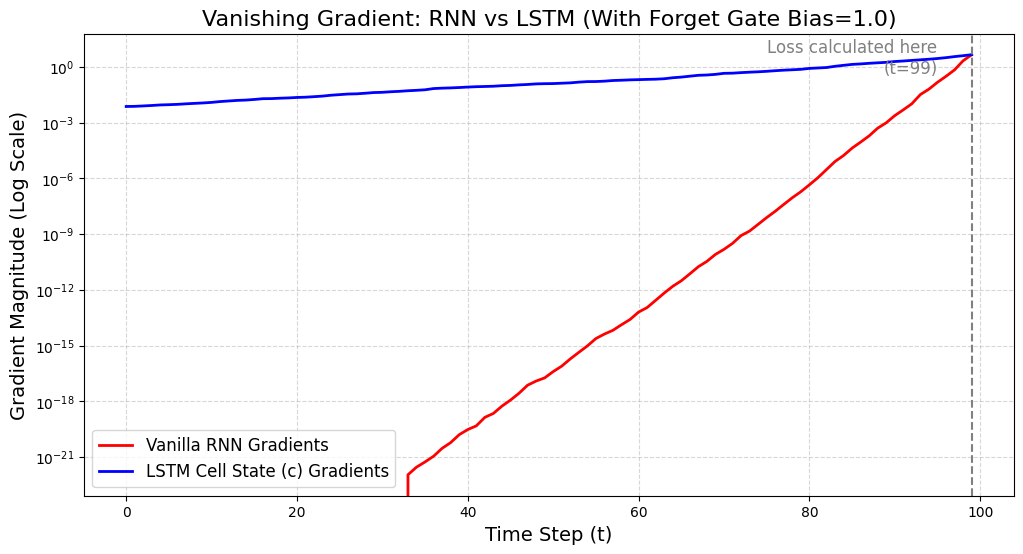

In [8]:
# ================= 绘图 =================
plt.figure(figsize=(12, 6))
time_steps = np.arange(seq_len)

plt.plot(time_steps, rnn_grads, label='Vanilla RNN Gradients', color='red', linewidth=2)
plt.plot(time_steps, lstm_c_grads, label='LSTM Cell State (c) Gradients', color='blue', linewidth=2)

plt.yscale('log')
plt.xlabel('Time Step (t)', fontsize=14)
plt.ylabel('Gradient Magnitude (Log Scale)', fontsize=14)
plt.title('Vanishing Gradient: RNN vs LSTM (With Forget Gate Bias=1.0)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.axvline(x=seq_len-1, color='gray', linestyle='--')
plt.text(seq_len-5, max(lstm_c_grads)*0.1, 'Loss calculated here\n(t=99)', 
         horizontalalignment='right', fontsize=12, color='gray')

plt.show()

In [21]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import copy

# ================= 1. 数据 =================
np.random.seed(42)
torch.manual_seed(42)

total_length = 50000
data = np.random.randn(total_length)
delay = 60
seq_len = 80

X, y = [], []
for i in range(len(data) - seq_len):
    X.append(data[i : i + seq_len])
    y.append(data[i + seq_len - delay])

X = torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(-1)
y = torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(-1)

train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# ================= 2. 模型 =================
class MemoryModel(nn.Module):
    def __init__(self, rnn_type='RNN', input_size=1, hidden_size=32):
        super().__init__()
        if rnn_type == 'RNN':
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        else:
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.linear(out[:, -1, :])

# 关键修正 1：隐藏层大小一致
HIDDEN = 64
model_rnn = MemoryModel(rnn_type='RNN', hidden_size=HIDDEN)
model_lstm = MemoryModel(rnn_type='LSTM', hidden_size=HIDDEN)

# ================= 3. 训练 =================
criterion = nn.MSELoss()
optimizer_rnn = torch.optim.Adam(model_rnn.parameters(), lr=0.005)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=0.005)

epochs = 200
rnn_losses, lstm_losses = [], []

# 关键修正 2：两个模型都保存最佳权重
best = {'rnn': (float('inf'), None), 'lstm': (float('inf'), None)}

print(f"开始训练 (Delay={delay}, Hidden={HIDDEN}, Epochs={epochs})...")


# 用 mini-batch 而不是全量梯度下降
from torch.utils.data import TensorDataset, DataLoader
train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

for epoch in range(epochs):
    # --- RNN ---
    model_rnn.train()
    ep_loss = 0
    for xb, yb in train_loader:
        optimizer_rnn.zero_grad()
        loss = criterion(model_rnn(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_rnn.parameters(), 1.0)
        optimizer_rnn.step()
        ep_loss += loss.item() * len(xb)
    rnn_losses.append(ep_loss / len(train_ds))
    if loss_rnn.item() < best['rnn'][0]:
        best['rnn'] = (loss_rnn.item(), copy.deepcopy(model_rnn.state_dict()))


    # --- LSTM ---
    model_lstm.train()
    ep_loss = 0
    for xb, yb in train_loader:
        optimizer_lstm.zero_grad()
        loss = criterion(model_lstm(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer_lstm.step()
        ep_loss += loss.item() * len(xb)
    lstm_losses.append(ep_loss / len(train_ds))

    
    if loss_lstm.item() < best['lstm'][0]:
        best['lstm'] = (loss_lstm.item(), copy.deepcopy(model_lstm.state_dict()))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d} | RNN Loss: {loss_rnn.item():.4f} | LSTM Loss: {loss_lstm.item():.4f}")

# 两个模型都恢复到各自最佳
model_rnn.load_state_dict(best['rnn'][1])
model_lstm.load_state_dict(best['lstm'][1])

# ================= 4. 评估 =================
model_rnn.eval(); model_lstm.eval()
with torch.no_grad():
    pred_rnn = model_rnn(X_test).numpy()
    pred_lstm = model_lstm(X_test).numpy()
    true_y = y_test.numpy()

def r2(true, pred):
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - true.mean()) ** 2)
    return 1 - ss_res / ss_tot

mse_rnn = np.mean((true_y - pred_rnn) ** 2)
mse_lstm = np.mean((true_y - pred_lstm) ** 2)
print(f"\n[Test] RNN  MSE={mse_rnn:.4f}  R2={r2(true_y, pred_rnn):.3f}")
print(f"[Test] LSTM MSE={mse_lstm:.4f}  R2={r2(true_y, pred_lstm):.3f}")
print(f"基线(预测均值) MSE ≈ {np.var(true_y):.4f}")

# ================= 5. 可视化 =================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(rnn_losses, label='RNN', color='red', alpha=0.8)
axes[0].plot(lstm_losses, label='LSTM', color='blue', alpha=0.8)
axes[0].axhline(np.var(y_train.numpy()), color='gray', ls=':', label='Variance baseline')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(alpha=0.3)

plot_len = 100
axes[1].plot(true_y[:plot_len], label='True', color='black', lw=2)
axes[1].plot(pred_rnn[:plot_len], label='RNN', color='red', ls='--')
axes[1].plot(pred_lstm[:plot_len], label='LSTM', color='blue', ls='-.')
axes[1].set_title('Test Prediction (first 100)'); axes[1].set_xlabel('Time'); axes[1].legend(); axes[1].grid(alpha=0.3)

# 预测值 vs 真实值散点，越靠近对角线越好
lim = [true_y.min(), true_y.max()]
axes[2].scatter(true_y, pred_rnn, s=8, color='red', alpha=0.4, label=f'RNN R2={r2(true_y,pred_rnn):.2f}')
axes[2].scatter(true_y, pred_lstm, s=8, color='blue', alpha=0.4, label=f'LSTM R2={r2(true_y,pred_lstm):.2f}')
axes[2].plot(lim, lim, 'k--', lw=1)
axes[2].set_title('Pred vs True'); axes[2].set_xlabel('True'); axes[2].set_ylabel('Pred'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

开始训练 (Delay=60, Hidden=64, Epochs=200)...
Epoch   50 | RNN Loss: 0.0243 | LSTM Loss: 0.3036
Epoch  100 | RNN Loss: 0.0243 | LSTM Loss: 0.3036


KeyboardInterrupt: 